In [37]:
import numpy as np
import matplotlib.pyplot as plt
import copy
import math
import tqdm
import os
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
import json
from scipy.spatial import ConvexHull
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from matplotlib.colors import TwoSlopeNorm, Normalize

In [33]:
def plot_direction_heat_mesh(dirs, values, title=None, cmap_name="bwr", orientation=True,save_path=None):
    values = np.asarray(values).ravel()

    triangles = ConvexHull(dirs).simplices
    face_values = values[triangles].mean(axis=1)

    if values.min() < 0 < values.max():
        norm = TwoSlopeNorm(vmin=values.min(), vcenter=0, vmax=values.max())
    else:
        norm = Normalize(vmin=values.min(), vmax=values.max())

    cmap = plt.get_cmap(cmap_name)

    fig = plt.figure(figsize=(7, 6))
    ax = fig.add_subplot(111, projection="3d")

    mesh = Poly3DCollection(
        dirs[triangles],
        facecolors=cmap(norm(face_values)),
        edgecolors=(0, 0, 0, 0.08),
        linewidths=0.15,
    )
    ax.add_collection3d(mesh)

    ax.set_xlim(-1, 1)
    ax.set_ylim(-1, 1)
    ax.set_zlim(-1, 1)
    ax.set_box_aspect((1,1,1))
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    if orientation:
        ax.view_init(elev=25, azim=45)
    else:
        ax.view_init(elev=25, azim=225)
    
    if title:
        ax.set_title(title)

    sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array(values)
    plt.colorbar(sm, ax=ax, shrink=0.7)

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

In [2]:
PatientID_list=['2','4','9','10','15','17','19','20','25','29','32','34','36','39','48']
test_PatientID_list=['52','56','57','65']

PatientID_list2=['0002','0004','0009','0010','0015','0017','0019','0020','0025','0029','0032','0034','0036','0039','0048']
test_PatientID_list2=['0052','0056','0057','0065']

In [5]:
with open("./output_bundle/right_output_3.json", "r", encoding="utf-8") as f:
    raw = json.load(f)

data3_right = {k: np.array(v) for k, v in raw.items()}

direct_right_3dslicer=[]
for i in PatientID_list:
    current_key='Lung segmentation-'+str(i)
    current_data=data3_right[current_key]
    direct_right_3dslicer.append(current_data)

direct_right_3dslicer=np.array(direct_right_3dslicer)

test_direct_right_3dslicer=[]
for i in test_PatientID_list:
    current_key='Lung segmentation-'+str(i)
    current_data=data3_right[current_key]
    test_direct_right_3dslicer.append(current_data)

test_direct_right_3dslicer=np.array(test_direct_right_3dslicer)

with open("./output_bundle/left_output_3.json", "r", encoding="utf-8") as f:
    raw = json.load(f)

data3_left = {k: np.array(v) for k, v in raw.items()}

direct_left_3dslicer=[]
for i in PatientID_list:
    current_key='Lung segmentation-'+str(i)
    current_data=data3_left[current_key]
    direct_left_3dslicer.append(current_data)

direct_left_3dslicer=np.array(direct_left_3dslicer)


test_direct_left_3dslicer=[]
for i in test_PatientID_list:
    current_key='Lung segmentation-'+str(i)
    current_data=data3_left[current_key]
    test_direct_left_3dslicer.append(current_data)
direct_left_3dslicer=np.array(direct_left_3dslicer)
test_direct_left_3dslicer=np.array(test_direct_left_3dslicer)




directLR_3dslicer=np.vstack((direct_right_3dslicer,direct_left_3dslicer))
direct_test_3dslicer=np.vstack((test_direct_right_3dslicer,test_direct_left_3dslicer))

In [6]:
with open("./output_bundle/output_1.json", "r", encoding="utf-8") as f:
    raw = json.load(f)

data1 = {k: np.array(v) for k, v in raw.items()}

direct5longest_3dslicer=[]
for i in PatientID_list:
    current_key='Lung segmentation-'+str(i)
    current_data=data1[current_key]
    direct5longest_3dslicer.append(current_data)
    
    
    
    
direct5longest_3dslicer=np.array(direct5longest_3dslicer)

In [7]:
with open("./output_bundle/right_output_4.json", "r", encoding="utf-8") as f:
    raw = json.load(f)

data4_right = {k: np.array(v) for k, v in raw.items()}
direct_right_medpseg=[]
for i in PatientID_list2:
    current_key=str(i)+'_airway'
    current_data=data4_right[current_key]
    direct_right_medpseg.append(current_data)
direct_right_medpseg=np.array(direct_right_medpseg)

test_direct_right_medpseg=[]
for i in test_PatientID_list2:
    current_key=str(i)+'_airway'
    current_data=data4_right[current_key]
    test_direct_right_medpseg.append(current_data)
test_direct_right_medpseg=np.array(test_direct_right_medpseg)

with open("./output_bundle/left_output_4.json", "r", encoding="utf-8") as f:
    raw = json.load(f)

data4_left = {k: np.array(v) for k, v in raw.items()}
direct_left_medpseg=[]
for i in PatientID_list2:
    current_key=str(i)+'_airway'
    current_data=data4_left[current_key]
    direct_left_medpseg.append(current_data)
direct_left_medpseg=np.array(direct_left_medpseg)

test_direct_left_medpseg=[]
for i in test_PatientID_list2:
    current_key=str(i)+'_airway'
    current_data=data4_left[current_key]
    test_direct_left_medpseg.append(current_data)
test_direct_left_medpseg=np.array(test_direct_left_medpseg)




directLR_medpseg=np.vstack((direct_right_medpseg,direct_left_medpseg))
direct_test_medpseg=np.vstack((test_direct_right_medpseg,test_direct_left_medpseg))

In [8]:
with open("./output_bundle/output_2.json", "r", encoding="utf-8") as f:
    raw = json.load(f)

data2 = {k: np.array(v) for k, v in raw.items()}
direct5longest_medpseg=[]
for i in PatientID_list2:
    current_key=str(i)+'_airway'
    current_data=data2[current_key]
    direct5longest_medpseg.append(current_data)
    
    
    
direct5longest_medpseg=np.array(direct5longest_medpseg)

In [9]:
print(direct5longest_3dslicer.shape)
print(direct5longest_medpseg.shape)
print(directLR_3dslicer.shape)
print(directLR_medpseg.shape)
print(direct_test_3dslicer.shape)
print(direct_test_medpseg.shape)

(15, 1630)
(15, 1630)
(30, 326)
(30, 326)
(8, 326)
(8, 326)


## Direct PHT: PCA Plots

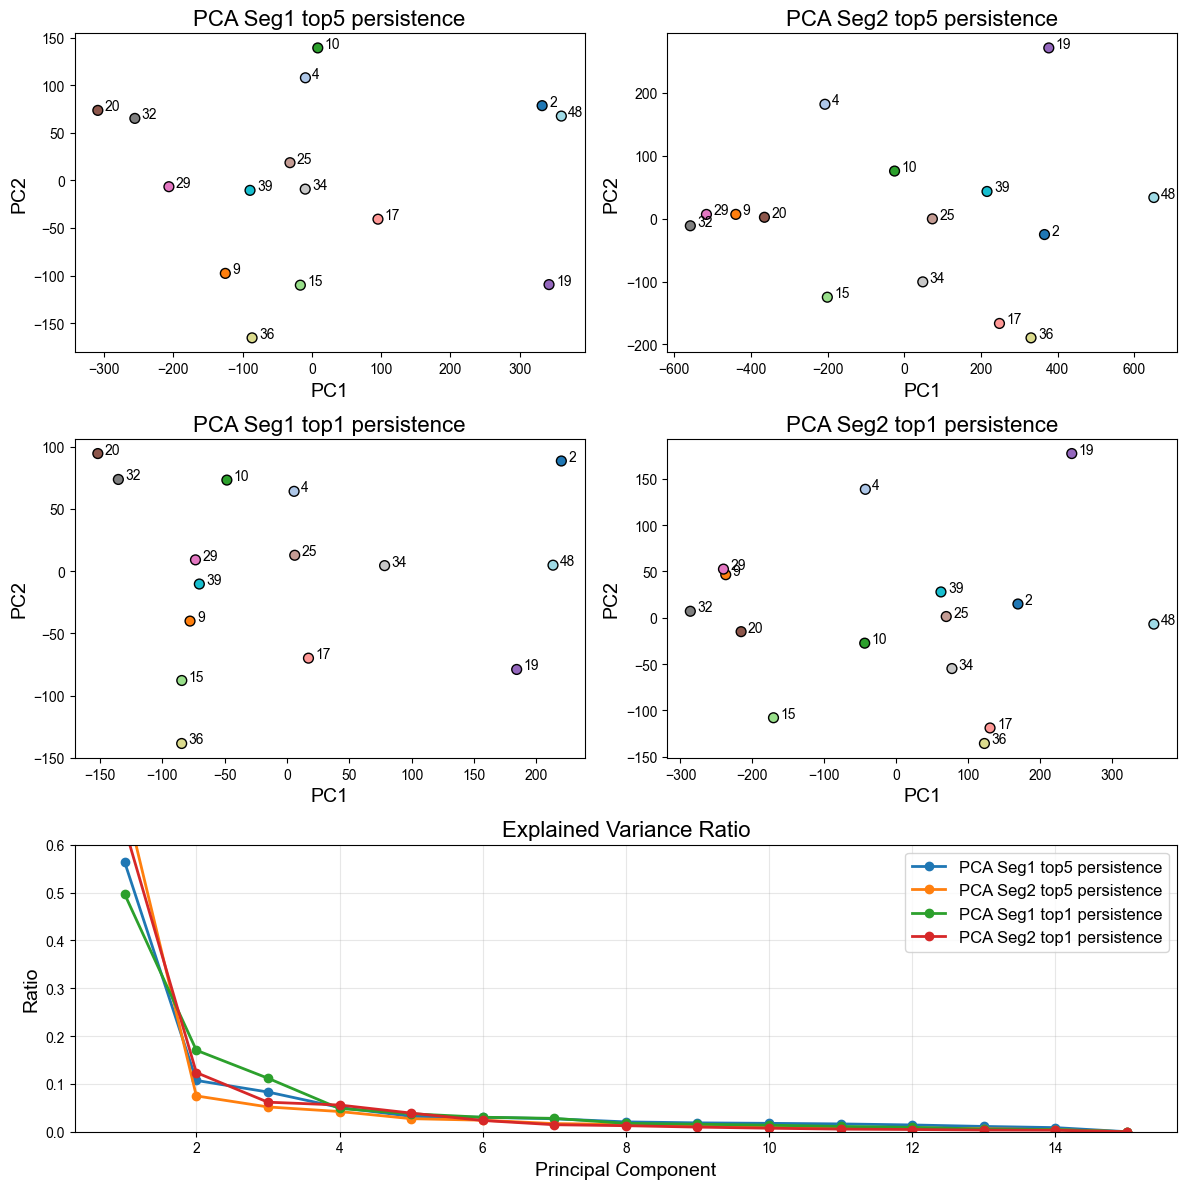

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

data_list = [direct5longest_3dslicer, direct5longest_medpseg, direct5longest_3dslicer[:,::5], direct5longest_medpseg[:,::5]]
titles = ["PCA Seg1 top5 persistence", "PCA Seg2 top5 persistence", "PCA Seg1 top1 persistence", "PCA Seg2 top1 persistence"]

id_to_num = {id_: i for i, id_ in enumerate(PatientID_list)}
num_labels = np.array([id_to_num[id_] for id_ in PatientID_list])

plt.rcParams["font.family"] = "Arial"

#---------------------------------------
# Figure layout
#---------------------------------------
fig = plt.figure(figsize=(12, 12))
gs = fig.add_gridspec(3, 2, height_ratios=[1, 1, 0.9])

scatter_axes = [
    fig.add_subplot(gs[0, 0]),
    fig.add_subplot(gs[0, 1]),
    fig.add_subplot(gs[1, 0]),
    fig.add_subplot(gs[1, 1]),
]

ax_var = fig.add_subplot(gs[2, :])

colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]

#---------------------------------------
# PCA for each dataset
#---------------------------------------
for ax_scatter, Results_list, title, color in zip(
        scatter_axes, data_list, titles, colors):

    pca = PCA()
    feature = pca.fit_transform(Results_list)

    x = feature[:, 0]
    y = feature[:, 1]

    # Scatter plot
    ax_scatter.scatter(
        x,
        y,
        c=num_labels,
        cmap="tab20",
        s=50,
        edgecolors="k"
    )

    for j, txt in enumerate(PatientID_list):
        ax_scatter.annotate(
            txt,
            (x[j], y[j]),
            xytext=(5, 0),
            textcoords="offset points",
            fontsize=10
        )

    ax_scatter.set_title(title, fontsize=16)
    ax_scatter.set_xlabel("PC1", fontsize=14)
    ax_scatter.set_ylabel("PC2", fontsize=14)

    # Explained variance ratio
    var_ratio = pca.explained_variance_ratio_

    ax_var.plot(
        np.arange(1, len(var_ratio)+1),
        var_ratio,
        marker="o",
        linewidth=2,
        color=color,
        label=title
    )

#---------------------------------------
# Common EVR plot
#---------------------------------------
ax_var.set_title("Explained Variance Ratio", fontsize=16)
ax_var.set_xlabel("Principal Component", fontsize=14)
ax_var.set_ylabel("Ratio", fontsize=14)
ax_var.set_ylim(0, 0.6)
ax_var.legend(fontsize=12)
ax_var.grid(alpha=0.3)

plt.tight_layout()
plt.show()

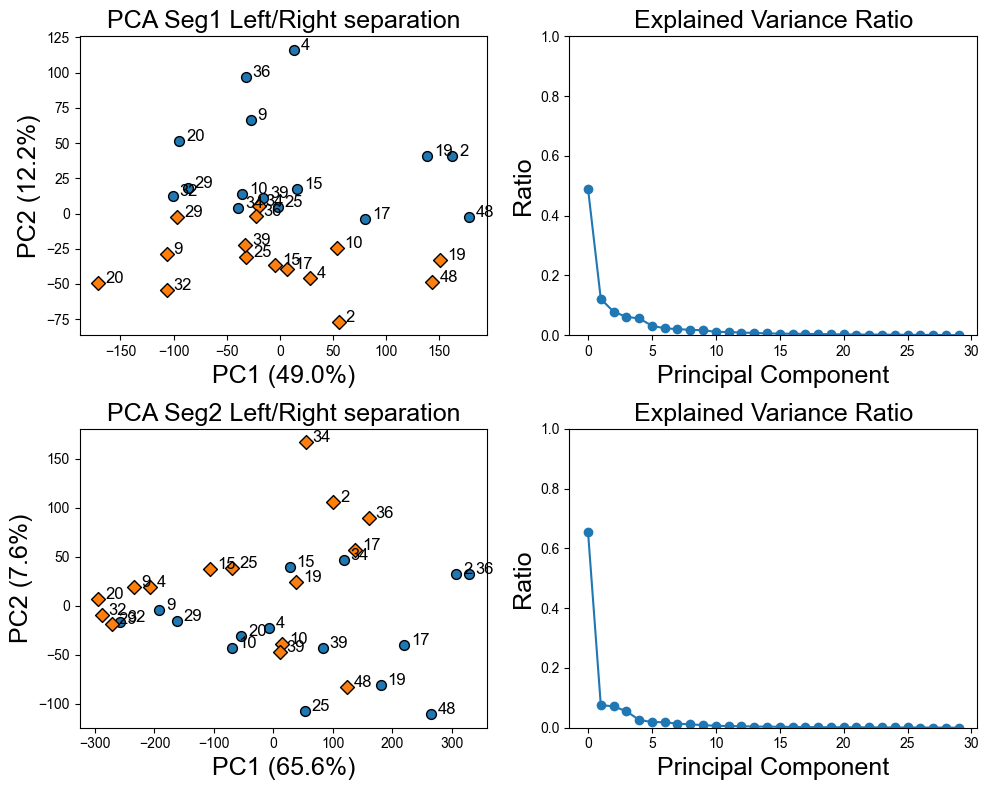

In [12]:
id_to_num = {id_: i for i, id_ in enumerate(PatientID_list)}
num_labels = np.array([id_to_num[id_] for id_ in PatientID_list])
plt.rcParams["font.family"] = "Arial"

data_list = [directLR_3dslicer, directLR_medpseg]
titles = ["PCA Seg1 Left/Right separation", "PCA Seg2 Left/Right separation"]

n = len(data_list)

fig, axes = plt.subplots(n, 2, figsize=(10, 4*n))

for i, (Results_list, title) in enumerate(zip(data_list, titles)):
    ax_scatter = axes[i, 0]
    ax_var = axes[i, 1]

    pca = PCA()
    feature = pca.fit_transform(Results_list)

    x1, y1 = feature[0:15, 0], feature[0:15, 1]
    ax_scatter.scatter(x1, y1, s=50, edgecolors='k')

    for j, txt in enumerate(PatientID_list):
        ax_scatter.annotate(txt, (x1[j], y1[j]),
                            xytext=(5, 0),
                            textcoords='offset points',
                            fontsize=12)

    x2, y2 = feature[15:30, 0], feature[15:30, 1]
    ax_scatter.scatter(x2, y2, s=50, edgecolors='k', marker='D')

    for j, txt in enumerate(PatientID_list):
        ax_scatter.annotate(txt, (x2[j], y2[j]),
                            xytext=(5, 0),
                            textcoords='offset points',
                            fontsize=12)

    var_ratio = pca.explained_variance_ratio_

    ax_scatter.set_title(title, fontsize=18)
    ax_scatter.set_xlabel(f"PC1 ({var_ratio[0]*100:.1f}%)", fontsize=18)
    ax_scatter.set_ylabel(f"PC2 ({var_ratio[1]*100:.1f}%)", fontsize=18)

    ax_var.plot(var_ratio, marker='o')
    ax_var.set_title("Explained Variance Ratio", fontsize=18)
    ax_var.set_xlabel("Principal Component", fontsize=18)
    ax_var.set_ylabel("Ratio", fontsize=18)
    ax_var.set_ylim(0, 1)

plt.tight_layout()
plt.show()

## RV Coefficient Calculation

In [13]:
### Definition of RV coefficient
def rv_coefficient(X, Y):
    X = X - X.mean(axis=0)### data centering
    Y = Y - Y.mean(axis=0)
    num = np.trace(X.T @ Y @ Y.T @ X)
    den = np.sqrt(np.trace(X.T @ X @ X.T @ X) * np.trace(Y.T @ Y @ Y.T @ Y))
    return num / den

In [14]:
### Cumulative explained variance ratio of the first 9 components for Direct PHT results
pca = PCA()
feature5_3dslicer = pca.fit_transform(direct5longest_3dslicer)
print(np.sum(np.array(pca.explained_variance_ratio_[0:9])))
pca = PCA()
feature5_medpseg = pca.fit_transform(direct5longest_medpseg)
print(np.sum(np.array(pca.explained_variance_ratio_[0:9])))
pca = PCA()
feature_3dslicer = pca.fit_transform(direct5longest_3dslicer[:,::5])
print(np.sum(np.array(pca.explained_variance_ratio_[0:9])))
pca = PCA()
feature_medpseg = pca.fit_transform(direct5longest_medpseg[:,::5])
print(np.sum(np.array(pca.explained_variance_ratio_[0:9])))

0.9323606062441576
0.962349502769363
0.9558416749773313
0.976143478613519


In [15]:
print("Direct PHT")
print("top5,2seg:",rv_coefficient(feature5_3dslicer[:,0:9],feature5_medpseg[:,0:9]))
print("top1,2seg:",rv_coefficient(feature_3dslicer[:,0:9],feature_medpseg[:,0:9]))
print("top5/1,Seg1:",rv_coefficient(feature5_3dslicer[:,0:9],feature_3dslicer[:,0:9]))
print("top5/1,Seg2:",rv_coefficient(feature5_medpseg[:,0:9],feature_medpseg[:,0:9]))

Direct PHT
top5,2seg: 0.6932038987571565
top1,2seg: 0.7173585639746944
top5/1,Seg1: 0.9128565726005242
top5/1,Seg2: 0.9575589067818895


In [16]:
### Class information for train dataset (half left. half right)
Class=np.array([0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1])
len(Class),len(np.where(Class==0)[0])

(30, 15)

In [17]:
### Seg1 with Direct PHT
for regval in [0.1,0.5,1,3,5]:
    print("========")
    print("C=",regval)
    lr = LogisticRegression(C=regval,penalty='l2',random_state=0, solver='liblinear') 
    lr.fit(directLR_3dslicer, Class)
    #print("coefficient = ", lr.coef_)
    #print("intercept = ", lr.intercept_)
    Y_pred = lr.predict(directLR_3dslicer)
    print("train data classification")
    print(Y_pred)
    Y_pred = lr.predict(direct_test_3dslicer)
    Y_proba=lr.predict_proba(direct_test_3dslicer)
    print("test data result")
    print('prediction:',Y_pred)
    print('prediction probability:')
    print(Y_proba)

C= 0.1
train data classification
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
test data result
prediction: [0 0 0 0 1 1 1 1]
prediction probability:
[[9.83988385e-01 1.60116153e-02]
 [7.02118444e-01 2.97881556e-01]
 [9.99454924e-01 5.45076293e-04]
 [9.97570807e-01 2.42919272e-03]
 [3.69571105e-03 9.96304289e-01]
 [1.00767078e-01 8.99232922e-01]
 [2.91142642e-02 9.70885736e-01]
 [3.81710413e-04 9.99618290e-01]]
C= 0.5
train data classification
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
test data result
prediction: [0 0 0 0 1 1 1 1]
prediction probability:
[[9.93900300e-01 6.09970006e-03]
 [7.44945197e-01 2.55054803e-01]
 [9.99923051e-01 7.69487661e-05]
 [9.99466066e-01 5.33933906e-04]
 [8.10048924e-04 9.99189951e-01]
 [6.26975329e-02 9.37302467e-01]
 [1.49082660e-02 9.85091734e-01]
 [5.78164501e-05 9.99942184e-01]]
C= 1
train data classification
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
test data result
prediction: [0 0 0 0 1 1 1 1

/Users/kiyoshitakeuchi/xpht/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/kiyoshitakeuchi/xpht/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/kiyoshitakeuchi/xpht/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.1

In [18]:
### Seg2 with Direct PHT
for regval in [0.1,0.5,1,3,5]:
    print("========")
    print("C=",regval)
    lr = LogisticRegression(C=regval,penalty='l2',random_state=0, solver='liblinear') 
    lr.fit(directLR_medpseg, Class)
    #print("coefficient = ", lr.coef_)
    #print("intercept = ", lr.intercept_)
    Y_pred = lr.predict(directLR_medpseg)
    print("train data classification")
    print(Y_pred)
    Y_pred = lr.predict(direct_test_medpseg)
    Y_proba=lr.predict_proba(direct_test_medpseg)
    print("test data result")
    print('prediction:',Y_pred)
    print('prediction probability:')
    print(Y_proba)

C= 0.1
train data classification
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
test data result
prediction: [0 0 0 0 1 1 1 1]
prediction probability:
[[9.94373079e-01 5.62692144e-03]
 [9.99315503e-01 6.84497359e-04]
 [9.98720024e-01 1.27997554e-03]
 [9.99998803e-01 1.19723387e-06]
 [2.17820353e-03 9.97821796e-01]
 [4.00535666e-03 9.95994643e-01]
 [1.26476881e-04 9.99873523e-01]
 [2.24605172e-01 7.75394828e-01]]
C= 0.5
train data classification
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
test data result
prediction: [0 0 0 0 1 1 1 1]
prediction probability:
[[9.98681193e-01 1.31880663e-03]
 [9.99853178e-01 1.46822257e-04]
 [9.99735130e-01 2.64870232e-04]
 [9.99999946e-01 5.43567022e-08]
 [8.40283424e-04 9.99159717e-01]
 [1.36013419e-03 9.98639866e-01]
 [1.88218991e-05 9.99981178e-01]
 [1.86442556e-01 8.13557444e-01]]
C= 1
train data classification
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
test data result
prediction: [0 0 0 0 1 1 1 1

/Users/kiyoshitakeuchi/xpht/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/kiyoshitakeuchi/xpht/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/kiyoshitakeuchi/xpht/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.1

In [19]:
### generalize across different segmentation methods
print("Direct PHT Seg1 > Seg2")
lr = LogisticRegression(C=1,penalty='l2',random_state=0, solver='liblinear') 
lr.fit(directLR_3dslicer, Class)
Y_pred = lr.predict(direct_test_medpseg)
print("test data result")
print('prediction:',Y_pred)

print("Direct PHT Seg2 > Seg1")
lr = LogisticRegression(C=1,penalty='l2',random_state=0, solver='liblinear') 
lr.fit(directLR_medpseg, Class)
Y_pred = lr.predict(direct_test_3dslicer)
print("test data result")
print('prediction:',Y_pred)

Direct PHT Seg1 > Seg2
test data result
prediction: [0 0 0 0 1 0 1 0]
Direct PHT Seg2 > Seg1
test data result
prediction: [0 1 0 0 1 1 1 1]


/Users/kiyoshitakeuchi/xpht/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/kiyoshitakeuchi/xpht/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


## Contribution Analysis

In [21]:
### PC2 for Projection PHT with Seg1 separated L/R clearly.
pca = PCA()
feature = pca.fit_transform(directLR_3dslicer)

In [22]:
### PC1 values are R negative, L positive
feature[:,1]

array([ 40.99697649, 116.16455965,  66.26704663,  13.89443927,
        17.29536373,  -3.66347571,  40.5710086 ,  51.24729706,
         4.68969061,  17.96226304,  12.64154089,   4.13484158,
        97.26838687,  11.27716892,  -2.70142093, -76.73506597,
       -45.86558195, -28.74520417, -24.48692175, -36.44227936,
       -39.10568077, -33.28657327, -49.32103493, -30.79472275,
        -2.65294489, -53.96523897,   5.69165906,  -1.42929843,
       -22.39781537, -48.50898317])

In [34]:
from persistent_homology import octahedron_directions

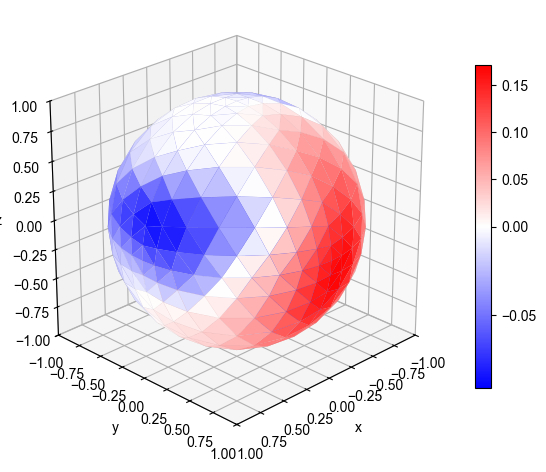

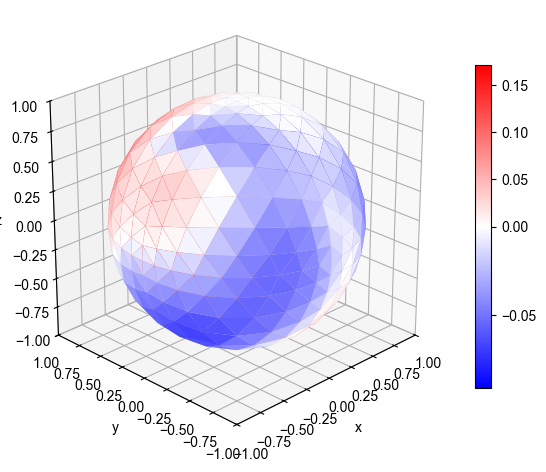

In [38]:
dirs = octahedron_directions()
loadings = pca.components_[1]

plot_direction_heat_mesh(
    dirs,
    loadings,
    orientation=True
)

plot_direction_heat_mesh(
    dirs,
    loadings,
    orientation=False
)

In [39]:
### Class information for train dataset (half left. half right)
Class=np.array([0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1])
len(Class),len(np.where(Class==0)[0])

(30, 15)

/Users/kiyoshitakeuchi/xpht/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


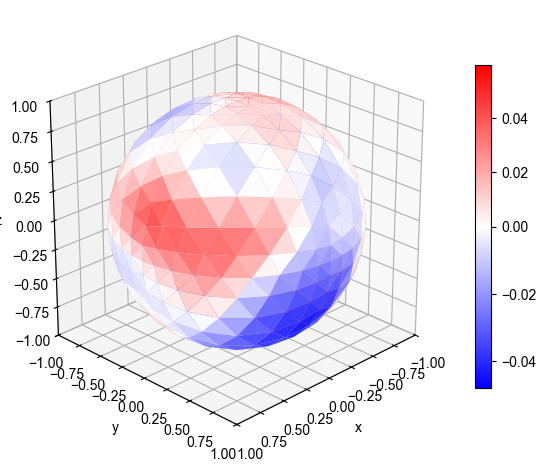

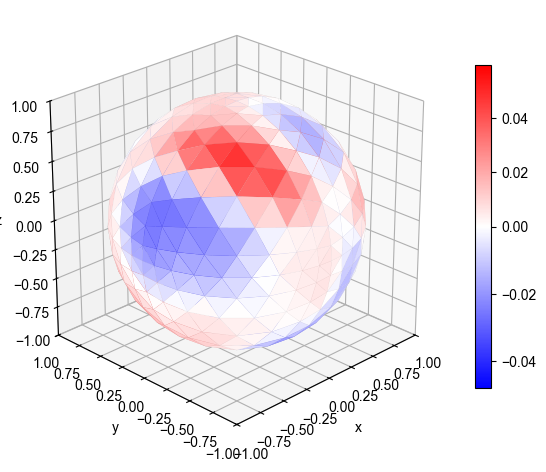

In [40]:
lr = LogisticRegression(C=1,penalty='l2',random_state=0, solver='liblinear') 
lr.fit(directLR_3dslicer, Class)
dirs = octahedron_directions()
loadings = lr.coef_.ravel()

plot_direction_heat_mesh(
    dirs,
    loadings,
    orientation=True
)

plot_direction_heat_mesh(
    dirs,
    loadings,
    orientation=False
)

/Users/kiyoshitakeuchi/xpht/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


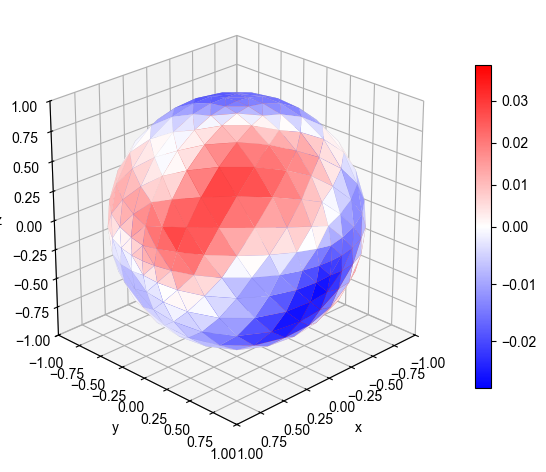

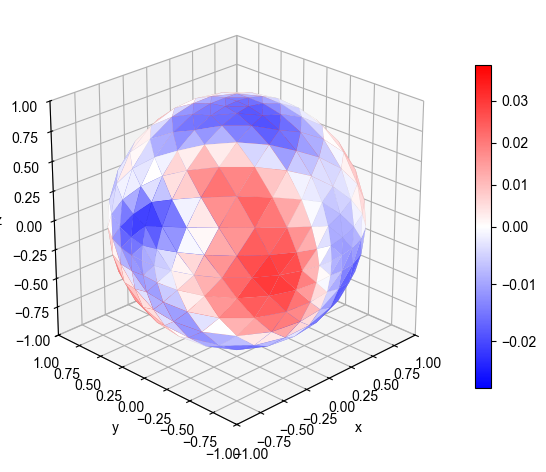

In [41]:
lr = LogisticRegression(C=1,penalty='l2',random_state=0, solver='liblinear') 
lr.fit(directLR_medpseg, Class)
dirs = octahedron_directions()
loadings = lr.coef_.ravel()

plot_direction_heat_mesh(
    dirs,
    loadings,
    orientation=True
)

plot_direction_heat_mesh(
    dirs,
    loadings,
    orientation=False
)